In [1]:
import sys
print(sys.executable)


c:\Users\tranp\AppData\Local\Programs\Python\Python310\python.exe


In [2]:
import cv2
print(cv2.__version__)


4.12.0


In [3]:
import cv2
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# 1. Haar Cascade
# -----------------------------
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

# -----------------------------
# 2. LBP Function
# -----------------------------
def lbp_feature(img_gray):
    lbp = np.zeros_like(img_gray)
    h, w = img_gray.shape

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            center = img_gray[i, j]
            code = 0
            code |= (img_gray[i-1, j-1] > center) << 7
            code |= (img_gray[i-1, j] > center) << 6
            code |= (img_gray[i-1, j+1] > center) << 5
            code |= (img_gray[i, j+1] > center) << 4
            code |= (img_gray[i+1, j+1] > center) << 3
            code |= (img_gray[i+1, j] > center) << 2
            code |= (img_gray[i+1, j-1] > center) << 1
            code |= (img_gray[i, j-1] > center)
            lbp[i, j] = code

    # Histogram LBP - features
    hist, _ = np.histogram(lbp.ravel(), bins=256, range=(0, 256))
    return hist


# -----------------------------
# 3. Load dataset from CASIA folder
# -----------------------------
def load_dataset(folder):
    X, y = [], []

    color_dir = os.path.join(folder, "color")
    files = os.listdir(color_dir)

    for file in files:
        if not file.endswith(".jpg"):
            continue

        label = 1 if "real" in file else 0

        img_path = os.path.join(color_dir, file)
        img = cv2.imread(img_path)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Detect face
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)
        if len(faces) == 0:
            continue

        x, y0, w, h = faces[0]
        face = gray[y0:y0 + h, x:x + w]

        face = cv2.resize(face, (128, 128))

        features = lbp_feature(face)
        X.append(features)
        y.append(label)

    return np.array(X), np.array(y)


# -----------------------------
# 4. RUN TRAIN & TEST
# -----------------------------
train_folder = "CASIA-FASD/train_img/train_img"
test_folder  = "CASIA-FASD/test_img/test_img"

print("Loading train...")
X_train, y_train = load_dataset(train_folder)

print("Loading test...")
X_test, y_test = load_dataset(test_folder)

print("Train RandomForest...")
clf = RandomForestClassifier(n_estimators=200, max_depth=30)
clf.fit(X_train, y_train)

# -----------------------------
# 5. Evaluation
# -----------------------------
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Loading train...


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'CASIA-FASD/train_img/train_img\\color'

In [ ]:
import matplotlib.pyplot as plt

def predict_image(img_path, model):
    img = cv2.imread(img_path)
    if img is None:
        print("Cannot load image:", img_path)
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect face
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    if len(faces) == 0:
        print("No face detected")
        return None

    x, y0, w, h = faces[0]
    face = gray[y0:y0+h, x:x+w]

    face = cv2.resize(face, (128, 128))

    feat = lbp_feature(face)

    feat = feat.reshape(1, -1)   # reshape cho sklearn
    pred = model.predict(feat)[0]
    prob = model.predict_proba(feat)[0]

    label = "REAL" if pred == 1 else "FAKE"

    # ----- Vẽ bounding box -----
    img_draw = img.copy()
    color = (0, 255, 0) if label == "REAL" else (0, 0, 255)
    cv2.rectangle(img_draw, (x, y0), (x+w, y0+h), color, 2)
    cv2.putText(img_draw, label, (x, y0 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    # Convert BGR → RGB để show bằng matplotlib
    img_rgb = cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Prediction: {label}  |  real={prob[1]:.2f}, fake={prob[0]:.2f}")
    plt.show()

    return label, prob

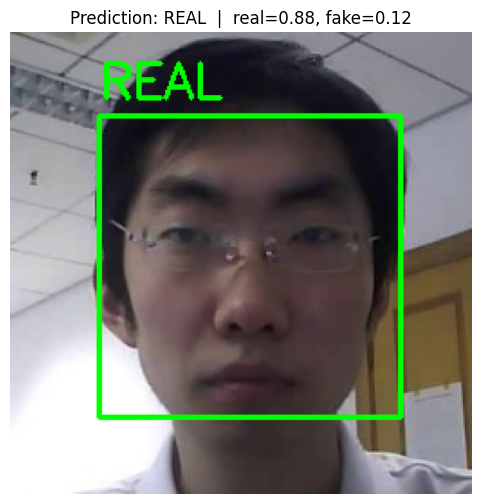

('REAL', array([0.12, 0.88]))

In [ ]:
# predict_image("/Users/mac/Documents/Software_self/VIS/VISBOX/server/lab/CASIA-FASD/train_img/train_img/color/1_1.avi_25_real.jpg", clf)

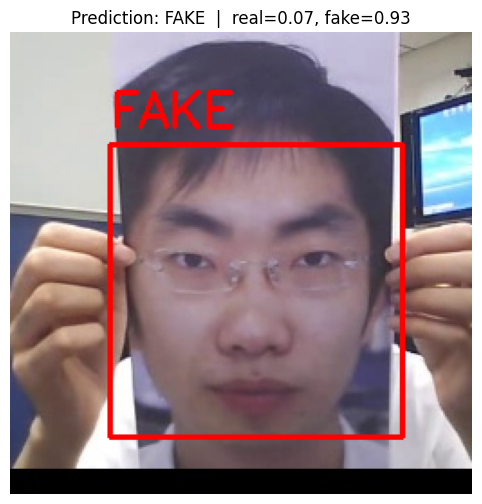

('FAKE', array([0.925, 0.075]))

In [ ]:
# predict_image("/Users/mac/Documents/Software_self/VIS/VISBOX/server/lab/CASIA-FASD/train_img/train_img/color/1_3.avi_25_fake.jpg", clf)

In [ ]:
import cv2

THRESHOLD = 0.6   # ngưỡng 85%

def run_realtime_camera(model):
    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print("Cannot open camera")
        return

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        for (x, y, w, h) in faces:
            face = gray[y:y+h, x:x+w]
            face_resized = cv2.resize(face, (128, 128))

            feat = lbp_feature(face_resized).reshape(1, -1)

            pred = model.predict(feat)[0]
            prob = model.predict_proba(feat)[0]
            
            prob_fake = prob[0]
            prob_real = prob[1]

            # ----- ÁP DỤNG NGƯỠNG 85% -----
            if prob_real >= THRESHOLD:
                label = "REAL"
                color = (0, 255, 0)
            else:
                label = "FAKE"
                color = (0, 0, 255)

            text = f"{label} ({prob_real:.2f})"

            cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
            cv2.putText(frame, text, (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

        cv2.imshow("Face Anti-Spoofing - Realtime", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()


In [ ]:
run_realtime_camera(clf)

: 